Initial shape: (29531, 16)
        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  
Shape after cleaning: (24850, 18)
Numeric features: ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']
Categorical fe

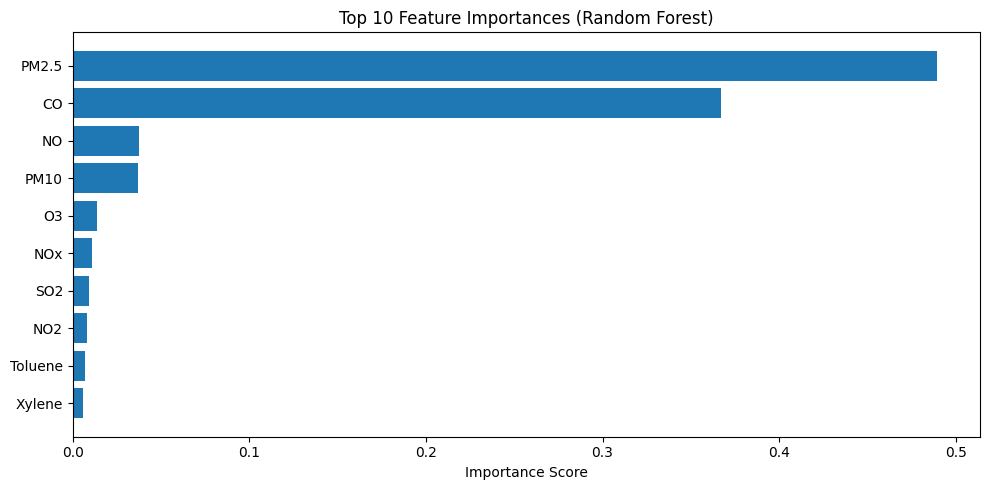

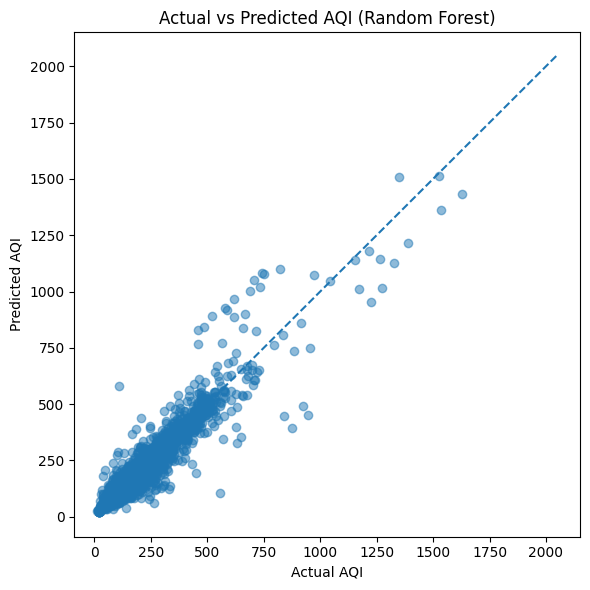


Model saved as: aqi_rf_model.joblib


In [ ]:
# ==============================================================
# Forecasting Air Quality Index (AQI) using Regression Models
# Dataset: city_day.csv (Kaggle - Air Quality India)
# Models: Linear Regression (Baseline) + Random Forest (Primary)
# Visualizations: Feature Importance + Scatter Plot
# ==============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib


# -----------------------------
# 1. Load Dataset
# -----------------------------
DATA_PATH = "/content/city_day.csv"
df = pd.read_csv(DATA_PATH)

print("Initial shape:", df.shape)
print(df.head())

# Standardize column names
df.columns = [col.strip().replace(" ", "_") for col in df.columns]

# -----------------------------
# 2. Basic Cleaning
# -----------------------------
target_col = "AQI"

df = df.dropna(subset=[target_col])

# Handle date column
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day
df["weekday"] = df["Date"].dt.weekday

df = df.drop(columns=["Date", "AQI_Bucket"], errors="ignore")

print("Shape after cleaning:", df.shape)

# -----------------------------
# 3. Feature/Target Split
# -----------------------------
X = df.drop(columns=[target_col])
y = df[target_col]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# -----------------------------
# 4. Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 5. Preprocessing
# -----------------------------
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# -----------------------------
# 6. Models
# -----------------------------
lin_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

rf_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200, random_state=42, n_jobs=-1
    ))
])

# -----------------------------
# 7. Train Models
# -----------------------------
lin_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# -----------------------------
# 8. Evaluation
# -----------------------------
def evaluate_model(name, model):
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n=== {name} ===")
    print(f"RMSE : {rmse:.3f}")
    print(f"MAE  : {mae:.3f}")
    print(f"R²   : {r2:.3f}")

    return y_pred


y_pred_lin = evaluate_model("Linear Regression", lin_model)
y_pred_rf  = evaluate_model("Random Forest", rf_model)

# -----------------------------
# 9. Feature Importance
# -----------------------------
rf = rf_model.named_steps["model"]
pre = rf_model.named_steps["preprocess"]

# get encoded feature names
cat_encoded = pre.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_features)
feature_names = np.concatenate([numeric_features, cat_encoded])

importances = rf.feature_importances_
fi_df = pd.DataFrame({"feature": feature_names, "importance": importances})
fi_df = fi_df.sort_values(by="importance", ascending=False)

print("\nTop 10 Important Features:")
print(fi_df.head(10))

# Plot Feature Importance
plt.figure(figsize=(10, 5))
plt.barh(fi_df.head(10)["feature"][::-1], fi_df.head(10)["importance"][::-1])
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# -----------------------------
# 10. Scatter Plot (Actual vs Predicted)
# -----------------------------
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI (Random Forest)")
plt.plot([y.min(), y.max()], [y.min(), y.max()], linestyle='--')
plt.tight_layout()
plt.show()

# -----------------------------
# 11. Save Final Model
# -----------------------------
joblib.dump(rf_model, "aqi_rf_model.joblib")
print("\nModel saved as: aqi_rf_model.joblib")

